[0]	validation_0-rmse:1.49980
[50]	validation_0-rmse:0.87317
[100]	validation_0-rmse:0.71905
[150]	validation_0-rmse:0.67478
[200]	validation_0-rmse:0.65903
[250]	validation_0-rmse:0.65345
[300]	validation_0-rmse:0.65309
[350]	validation_0-rmse:0.65292
[400]	validation_0-rmse:0.65340
[450]	validation_0-rmse:0.65509
[500]	validation_0-rmse:0.65493
[550]	validation_0-rmse:0.65547
[600]	validation_0-rmse:0.65561
[650]	validation_0-rmse:0.65489
[700]	validation_0-rmse:0.65521
[750]	validation_0-rmse:0.65507
[800]	validation_0-rmse:0.65561
[850]	validation_0-rmse:0.65558
[900]	validation_0-rmse:0.65542
[950]	validation_0-rmse:0.65535
[999]	validation_0-rmse:0.65515


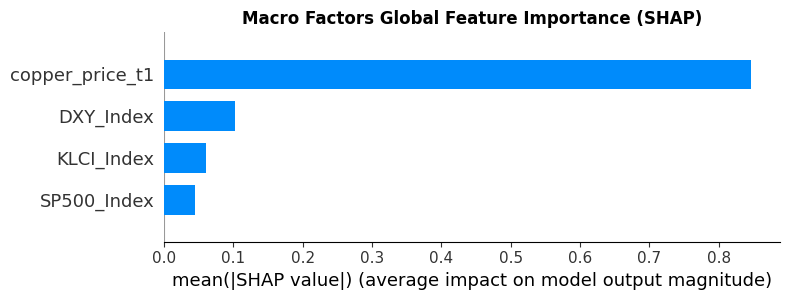

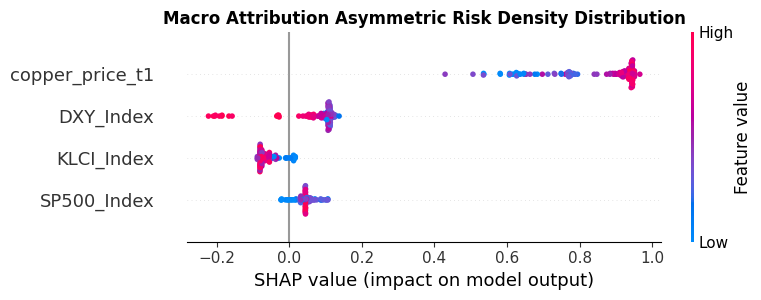

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

# ==========================================
# # 1. 数据清洗与索引规范
# ==========================================
# 直接读取本地的金融宏观特征对齐宽表
df = pd.read_csv('final_financial_data.csv')

# 保证时间序列严格按交易日期升序排列，防止时序训练混乱
df['Trade_Date'] = pd.to_datetime(df['Trade_Date'])
df = df.sort_values('Trade_Date').reset_index(drop=True)

# 💡 动态检查并构建动量滞后特征：金融预测中 t-1 期的资产自身价格极其核心
if 'copper_price_t1' not in df.columns:
    df['copper_price_t1'] = df['Copper_Price'].shift(1)
    df = df.dropna().reset_index(drop=True) # 剔除首行因平移产生的空值

# ==========================================
# # 2. 准备模型特征矩阵与时序验证集切分（严防数据泄露）
# ==========================================
# 显式定义外生宏观特征与动量滞后项
feature_cols = ['DXY_Index', 'SP500_Index', 'KLCI_Index', 'copper_price_t1']
target_col = 'Copper_Price'

X = df[feature_cols]
y = df[target_col]

# 严格执行时序切分（Out-of-Time Validation，禁止交叉验证以防时间穿越泄露）
# 前 80% 历史样本作为训练集，后 20% 最新样本留作盲测验证集
split_idx = int(len(df) * 0.8)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

# ==========================================
# # 3. 生产级 XGBoost 树模型拟合（部署过拟合早停机制）
# ==========================================
# 精细调节超参数，调低学习率（0.03）以确保稳健收敛，树深限制在 6 层防止结构性过拟合
model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist' 
)

# 传入时序验证集进行全量动态损失监测
# 一旦盲测集的 RMSE 损失连续 50 棵树不再下降，则立刻触发 Early Stopping 强行停机
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50 # 每迭代 50 次打印一次训练和验证损耗轨迹
)

# ==========================================
# # 4. 白盒模型可解释性分析与矩阵化输出 (TreeSHAP Evaluation)
# ==========================================
# 实例化针对树模型的 TreeExplainer 解释器，并解析测试集
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val)

# 图 1：宏观特征全局贡献度柱状图（Global Feature Importance）
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
plt.title("Macro Factors Global Feature Importance (SHAP)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show() 

# 图 2：非对称风险密度分布图（Dynamic Risk Attribution Summary Plot）
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, show=False)
plt.title("Macro Attribution Asymmetric Risk Density Distribution", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show() 

In [7]:
# ==========================================
# # 5. 导出预测结果与 SHAP 矩阵，为可视化系统供数
# ==========================================
# 1. 导出验证集的真实值与模型预测值（用于前端绘制价格预测对齐曲线）
df_viz = X_val.copy()
df_viz['Actual_Price'] = y_val
df_viz['Predicted_Price'] = model.predict(X_val)
df_viz['Trade_Date'] = df.iloc[split_idx:]['Trade_Date'].values
df_viz.to_csv('dashboards/data_model_predictions.csv', index=False)

# 2. 导出 SHAP 矩阵（用于前端或者大厂 BI 还原非对称密度分布图）
df_shap = pd.DataFrame(shap_values.values, columns=[f'SHAP_{col}' for col in feature_cols])
df_shap['Trade_Date'] = df.iloc[split_idx:]['Trade_Date'].values
df_shap.to_csv('dashboards/data_shap_values.csv', index=False)

print("🚀 工业级看板数据源已成功无缝导出至 dashboards/ 目录！")

🚀 工业级看板数据源已成功无缝导出至 dashboards/ 目录！
